# Tutorial 3: Building a Ground-Truth Dataset
### Full workflow: data collection → model labeling → export

---

This notebook walks you through the **complete pipeline** for building a geo-referenced, model-labeled urban dataset:

```
Study area
    │
    ▼
Building footprints  ───────────────────────────────────────────────┐
    │                                                               │
    ▼                                                               │
Street-view collection  ←── checkpoint (resume-safe)                │
    │                                                               │
    ▼                                                               │
VLM labeling  ←── checkpoint (resume-safe)                          │
    │         \                                                     │
    │          └── API models (Claude / GPT-4o / Gemini)            │
    ▼                                                               │
export()  →  metadata.csv  +  images/                               │
    │                                                               │
    └───────────────────────────────────────────────────── join ───►┘
                                             geo-labeled GeoDataFrame
```

**What's new in this tutorial (v0.2+)**
| Feature | What it does |
|---|---|
| `checkpoint_path` on collection | Crash mid-run? Resume from the last saved location. |
| `checkpoint_path` on inference | Same for labeling — no re-running 400 images because image 401 failed. |
| `InferenceAPI` | Use Claude, GPT-4o, or Gemini as the labeler — same interface as local backends. |
| `gtd.export()` | One call produces an organized `images/` folder + `metadata.csv` with labels merged in. |

**Study area:** a residential block in Detroit, Michigan, USA.  
**Task:** label each house as *occupied* or *unoccupied*.

## Prerequisites

**You'll need at least one of these to run the labeling steps:**

| What | Why |
|---|---|
| [Mapillary API token](https://www.mapillary.com/dashboard/developers) (free) | Collect street-view images |
| [Ollama](https://ollama.com/) installed locally | Local VLM labeling (free) |
| [llama-mtmd-cli](https://github.com/ggml-org/llama.cpp) installed | Alternative local VLM |
| [Anthropic API key](https://console.anthropic.com/) / [OpenAI](https://platform.openai.com/) / [Google](https://aistudio.google.com/) | API-model labeling |

> **Tip:** You can still follow most of this tutorial with only a Mapillary key. The labeling cells will show you the expected output shape so you know what to expect before you set up a VLM.

**Install urbanworm:**

In [ ]:
# Install the core package + Ollama support.
# For API-model labeling also add: pip install "urban-worm[api]"
# For Unsloth (GPU) labeling:     pip install "urban-worm[unsloth]"
%pip install "urban-worm[ollama]" --quiet

---
## 0 · Imports and API keys

In [1]:
import os
import pandas as pd
import geopandas as gpd
from pathlib import Path
from typing import Literal

from urbanworm import (
    GeoTaggedData,
    InferenceOllama,
    InferenceLlamacpp,
)
# InferenceAPI and InferenceUnsloth are imported lazily (only when used) to
# avoid pulling in heavy optional SDKs on startup.

In [2]:
# ── API keys ──────────────────────────────────────────────────────────────
# Option A: read from the text files shipped with the docs/ folder.
# Option B: set environment variables and leave the file paths empty.

def _read_key(path, env_var):
    """Read a key from a file, falling back to an environment variable."""
    p = Path(path)
    if p.exists():
        return p.read_text().strip()
    return os.getenv(env_var, "")

MAPILLARY_KEY = _read_key("mapillary_key.txt", "MAPILLARY_API_KEY")

# Only needed if you use InferenceAPI later:
ANTHROPIC_KEY = os.getenv("ANTHROPIC_API_KEY", "")
OPENAI_KEY    = os.getenv("OPENAI_API_KEY",    "")
GOOGLE_KEY    = os.getenv("GOOGLE_API_KEY",     "")

if not MAPILLARY_KEY:
    print("⚠️  No Mapillary key found. Street-view collection cells will be skipped.")
else:
    print("Mapillary key loaded ✓")

Mapillary key loaded ✓


---
## 1 · Define your study area

We'll work with a small residential block in Detroit.  
`getBuildings()` pulls building footprints from OpenStreetMap — you only need a bounding box.

> **Tip:** To find a bounding box for any area, open [bboxfinder.com](http://bboxfinder.com/), draw a rectangle, and copy the coordinates in `(min_lon, min_lat, max_lon, max_lat)` order.

In [3]:
# 1.1  Get building footprints from OpenStreetMap
gtd = GeoTaggedData()

BBOX = (-83.208003, 42.374646, -83.206608, 42.375328)  # Detroit, MI

gtd.getBuildings(
    bbox=BBOX,
    source='osm',      # 'osm' | 'microsoft' | 'globfp3d' | 'gba'
    max_area=300,      # drop huge buildings (e.g. warehouses) — keep houses ≤ 300 m²
    min_area=60
)

print(f"Found {len(gtd.units)} buildings")
gtd.units.head()

Found 14 buildings


,geometry
0,"POLYGON ((-83.20702 42.37478, -83.20688 42.374..."
1,"POLYGON ((-83.20702 42.3749, -83.20688 42.3749..."
2,"POLYGON ((-83.20704 42.37499, -83.2069 42.3749..."
3,"POLYGON ((-83.20703 42.37509, -83.20691 42.375..."
4,"POLYGON ((-83.20703 42.37514, -83.20706 42.375..."


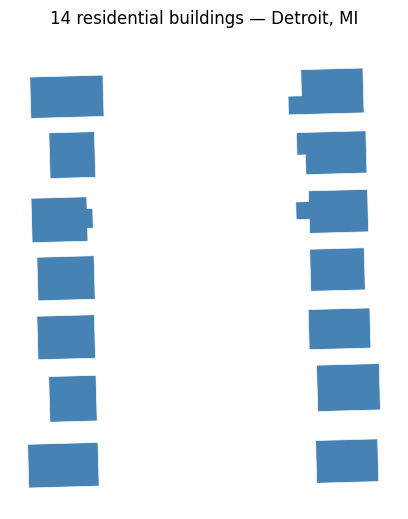

In [4]:
# 1.2  Quick map
# Each red dot is a building centroid that will be looked up in Mapillary.
ax = gtd.units.plot(figsize=(8, 6), color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title(f"{len(gtd.units)} residential buildings — Detroit, MI")
ax.set_axis_off()

---
## 2 · Collect street views — with crash-safe checkpointing

### Two separate steps

urbanworm keeps **fetching** and **downloading** cleanly separated:

| Step | Method | What it does | Resume strategy |
|---|---|---|---|
| 1 — Fetch | `get_svi_from_locations(checkpoint_path=...)` | Calls the Mapillary API and stores the returned base64 images (or URLs) in memory | JSONL checkpoint — already-fetched locations are skipped instantly |
| 2 — Download | `download_to_dir(data='svi', to_dir=...)` | Writes the fetched images to disk | Filesystem — already-written files are never overwritten |

### Why a JSONL checkpoint for fetching?

Fetching street views for hundreds of locations over a slow connection (or a flaky API) can take
a long time. Without checkpointing, a crash at location 200 means starting over from zero.

Pass **`checkpoint_path`** to `get_svi_from_locations` and urbanworm will:
1. Write one JSON line after each location is successfully fetched (storing the raw base64 data).
2. On the next run, read the JSONL, skip every `loc_id` already in it, and continue from where it left off.

The checkpoint is a plain text file — one JSON object per line, easy to inspect in any text editor:

```
my_run/
  svi.jsonl          ← one line per completed location (stores raw fetched data)
```

### Why is `download_to_dir` already resume-safe?

`download_to_dir` checks whether each target file exists before writing it.  
Re-run it at any point after a crash — already-written files are skipped, the rest are downloaded.  
No extra checkpoint file is needed.

In [6]:
# ── 2.1  Fetch street views (crash-safe) ─────────────────────────────────
# The first run calls the Mapillary API for every building and writes svi.jsonl.
# Re-run this cell at any time — already-fetched locations are skipped instantly.

RUN_DIR = Path("my_dataset_run")   # all checkpoint files land here
RUN_DIR.mkdir(exist_ok=True)

if MAPILLARY_KEY:
    gtd.get_svi_from_locations(
        key=MAPILLARY_KEY,
        distance=30,          # max distance from building centroid to street view (metres)
        pano=True,            # panoramic images only (better for reorientation)
        reoriented=True,      # auto-crop and reorient to face the building
        fov='auto',           # auto-compute field-of-view from the building footprint
        time_of_day='day',    # daylight images only
        multi_num=2,          # up to 2 views per building (from different angles)
        silent=True,
        # ↓ new: pass any path to a .jsonl file to enable crash-safe checkpointing
        checkpoint_path=str(RUN_DIR / "svi.jsonl"),
    )
    print(f"\nFetched {len(gtd.svis['id'])} street views across {len(gtd.units)} buildings")
else:
    print("Skipping collection (no Mapillary key). Set MAPILLARY_KEY above to run this step.")

  0%|          | 0/14 [00:00<?, ?it/s]


Fetched 28 street views across 14 buildings


In [7]:
# ── 2.2  Download images to disk ──────────────────────────────────────────
# After fetching, write the images to a local folder.
# This step is already resume-safe: files that already exist on disk are
# never re-downloaded.  Re-run freely after any interruption.

IMAGES_DIR = RUN_DIR / "images"
IMAGES_DIR.mkdir(exist_ok=True)

if gtd.svis.get('id'):   # only run if we have fetched data
    gtd.download_to_dir(data='svi', to_dir=str(IMAGES_DIR))
    img_files = list(IMAGES_DIR.glob('*.png'))
    print(f"Images on disk: {len(img_files)}")
else:
    print("No street views in memory yet — run the fetch cell above first.")

  0%|          | 0/28 [00:00<?, ?it/s]

Images on disk: 28


In [8]:
# ── 2.3  Inspect the checkpoint file ─────────────────────────────────────
# Each line is one location. You can read it with pandas or plain json.
ckpt_path = RUN_DIR / "svi.jsonl"

if ckpt_path.exists():
    ckpt_df = pd.read_json(ckpt_path, lines=True)
    print(f"Checkpoint: {len(ckpt_df)} locations saved")
    print(f"Columns: {list(ckpt_df.columns)}")
    # 'data' holds the raw fetched base64 strings / URLs.
    # 'paths' is always [] here — it is populated by download_to_dir().
    ckpt_df[['loc_id', 'ids']].head()
else:
    print("No checkpoint file yet — run the fetch cell above first.")

Checkpoint: 14 locations saved
Columns: ['loc_id', 'ids', 'paths', 'data', 'metadata']


In [9]:
# ── 2.4  Demonstrate resume ───────────────────────────────────────────────
# Create a fresh GeoTaggedData and call get_svi_from_locations again.
# Because svi.jsonl already exists, every location is skipped immediately
# — the raw fetched data is restored directly from the JSONL, no API calls.

if MAPILLARY_KEY and ckpt_path.exists():
    gtd2 = GeoTaggedData()
    gtd2.getBuildings(bbox=BBOX, source='osm', max_area=300)

    import time
    t0 = time.time()
    gtd2.get_svi_from_locations(
        key=MAPILLARY_KEY,
        distance=30,
        pano=True,
        reoriented=True,
        fov='auto',
        time_of_day='day',
        multi_num=2,
        silent=True,
        checkpoint_path=str(RUN_DIR / "svi.jsonl"),  # same file!
    )
    elapsed = time.time() - t0
    print(f"Resume completed in {elapsed:.1f}s — {len(gtd2.svis['id'])} views restored from checkpoint")
    print("(All locations were already done, so nothing was re-fetched from the API.)")
    del gtd2

    # You still need to call download_to_dir() if you want the images on disk.
    # But since we already did that in cell 2.2, nothing new will be written:
    # every file already exists, so they are all skipped.

  0%|          | 0/19 [00:00<?, ?it/s]

Resume completed in 23.8s — 38 views restored from checkpoint
(All locations were already done, so nothing was re-fetched from the API.)


In [10]:
# ── 2.4  Tell the dataset which images to use for inference ───────────────
# This points the inference constructors at the street-view images.
gtd.set_images('svi')

print(f"Images ready: {len(gtd.images['id'])} total")
print(f"Using local paths: {any(p for p in gtd.images['path'])}")

Images ready: 28 total
Using local paths: True


---
## 3 · Design your labeling schema

The schema controls what the model outputs. It's a plain Python dict mapping field names to `(type, default)` tuples — the same format across **all** backends (Ollama, llama.cpp, Unsloth, API models).

### Good practices for ground-truth schemas

| Do | Why |
|---|---|
| Use `Literal[...]` for categorical answers | Forces the model to pick from a fixed set; avoids free-text variants like "Yes", "yes", "YES" |
| Add an `explanation` or `evidence` field | Helps you catch hallucinations when reviewing labels |
| Keep categories mutually exclusive | Ambiguous categories produce noisy labels |
| Start with 2–3 categories | Harder tasks need a stronger model — verify quality before scaling |

> **Note:** The schema is passed once at construction time. You can reuse the same `GeoTaggedData` object with multiple different schemas.

In [14]:
# ── 3.1  Define the labeling schema ───────────────────────────────────────
# Task: is this house occupied or not?

LABEL_SCHEMA = {
    # A Literal type restricts the model to only these exact values.
    "occupancy": (Literal["occupied", "unoccupied"], ...),

    # An explanation field is optional but highly recommended —
    # it lets you audit the model's reasoning per label.
    "visual_evidence": (str, ...),
}

# System prompt: set the model's role and any domain context.
SYSTEM_PROMPT = """
You are an urban researcher assessing housing conditions from street-level imagery.
Focus only on the building directly visible in the image.
Ignore people, vehicles, and background structures.
""".strip()

# User prompt: the actual question.
USER_PROMPT = """
Look at the house in this image.

Classify its occupancy:
- occupied:   visible signs of habitation (lights, curtains, maintained yard, vehicles, decorations)
- unoccupied: visible signs of vacancy (boarded windows, overgrown yard, structural damage, graffiti)
- uncertain:  image quality too low, or house not clearly visible

Then briefly describe the visual evidence you used (1–2 sentences).
""".strip()

print("Schema defined:")
for field, (ftype, _) in LABEL_SCHEMA.items():
    print(f"  {field}: {ftype}")

Schema defined:
  occupancy: typing.Literal['occupied', 'unoccupied']
  visual_evidence: <class 'str'>


---
## 4 · Label with a local VLM

Local models are **free** (after setup) and keep your data private. Two backends are available:

| Backend | Best for | Install |
|---|---|---|
| **Ollama** | Quick setup, any Ollama-compatible model | `pip install "urban-worm[ollama]"` + [install Ollama](https://ollama.com/) |
| **llama.cpp** | Highly customizable sampling, audio support | [install llama-mtmd-cli](https://github.com/ggml-org/llama.cpp) |
| **Unsloth** | GPU batching for large datasets | `pip install "urban-worm[unsloth]"` |

All three share the same `batch_inference(system, prompt, checkpoint_path)` interface.

### 4.1 · Ollama

> **Setup (one-time):**  
> 1. Install Ollama from [ollama.com](https://ollama.com/)  
> 2. The model is pulled automatically on first use

In [16]:
# 4.1  Ollama inference with checkpointing
# On first run: fetches the model and processes every image, writing a
# checkpoint record after each one.
# On every subsequent run: already-done images are restored from the
# checkpoint and skipped — only new images are processed.

inf_ollama = InferenceOllama(
    llm='hf.co/ggml-org/InternVL3-8B-Instruct-GGUF:Q8_0',
    geo_tagged_data=gtd,
    schema=LABEL_SCHEMA,
)

df_ollama = inf_ollama.batch_inference(
    system=SYSTEM_PROMPT,
    prompt=USER_PROMPT,
    # ↓ new: same checkpoint_path pattern as collection
    checkpoint_path=str(RUN_DIR / "labels_ollama.jsonl"),
)

print(f"Labeled {len(df_ollama)} images")
df_ollama.head()

Processing...: 0it [00:00, ?it/s]

Labeled 28 images


,occupancy1,visual_evidence1,data
0,uncertain,The image quality is relatively clear but lack...,./my_dataset_run/images/0_1027528699347642.png
1,uncertain,The image is overexposed and lacks clear detai...,./my_dataset_run/images/0_1742398326699208.png
2,uncertain,The image is of poor quality and does not prov...,./my_dataset_run/images/1_1027528699347642.png
3,uncertain,"The image quality is relatively clear, but the...",./my_dataset_run/images/1_1742398326699208.png
4,uncertain,The image quality is clear enough to see that ...,./my_dataset_run/images/2_576728614982524.png


In [17]:
# 4.1b  What the checkpoint looks like
inf_ckpt = RUN_DIR / "labels_ollama.jsonl"
if inf_ckpt.exists():
    inf_ckpt_df = pd.read_json(inf_ckpt, lines=True)
    print(f"{len(inf_ckpt_df)} records saved")
    # Each record: {idx, responses: [{occupancy: ..., visual_evidence: ...}], data: <path>}
    inf_ckpt_df.head(3)

28 records saved


### 4.2 · llama.cpp (alternative)

> **Setup (one-time):**  
> macOS: `brew install llama.cpp`  
> Windows: use the [llama.cpp releases](https://github.com/ggml-org/llama.cpp/releases)

In [ ]:
# 4.2  llama.cpp inference with checkpointing
# llm can be a HuggingFace model id (downloaded on first use) or a local .gguf path.

inf_llama = InferenceLlamacpp(
    llm="ggml-org/InternVL3-8B-Instruct-GGUF:Q8_0",
    geo_tagged_data=gtd,
    schema=LABEL_SCHEMA,
)

df_llama = inf_llama.batch_inference(
    system=SYSTEM_PROMPT,
    prompt=USER_PROMPT,
    temp=0.2,
    ctx_size=4096,
    checkpoint_path=str(RUN_DIR / "labels_llama.jsonl"),
)

print(f"Labeled {len(df_llama)} images")
df_llama.head()

### 4.3 · Unsloth (GPU, optional)

If you have a GPU, Unsloth can process many images in parallel using `batch_size > 1`.

In [ ]:
# 4.3  Unsloth inference (GPU)
# Lazy import — only loads torch/unsloth when this cell is executed.
from urbanworm import InferenceUnsloth

inf_unsloth = InferenceUnsloth(
    llm="unsloth/Qwen3-VL-3B-Instruct",
    load_in_4bit=True,           # 4-bit quantization: cuts VRAM in half
    geo_tagged_data=gtd,
    schema=LABEL_SCHEMA,
)

df_unsloth = inf_unsloth.batch_inference(
    system=SYSTEM_PROMPT,
    prompt=USER_PROMPT,
    batch_size=4,                # process 4 images at once (tune for your VRAM)
    checkpoint_path=str(RUN_DIR / "labels_unsloth.jsonl"),
)

print(f"Labeled {len(df_unsloth)} images")
df_unsloth.head()

---
## 5 · Label with an API model

Frontier API models (Claude, GPT-4o, Gemini) are generally more reliable labelers than small local VLMs, especially for:
- **Nuanced categories** (e.g. subtle maintenance signs)
- **Low-quality or tricky images** (glare, occlusion)
- **Generating high-quality ground truth** that will train or evaluate smaller models

The trade-off is cost — use API models on a **random sample** to establish gold labels, then use those labels to calibrate or fine-tune a cheaper local model.

> **Cost rule of thumb:**  
> ~1 000 images × ~500 tokens/call = ~500k tokens ≈ **$1–2** with GPT-4o-mini or Claude Haiku.

`InferenceAPI` has the **exact same interface** as the local backends — same `schema`, same `system`/`prompt`, same `checkpoint_path`.

In [ ]:
# 5.1  Anthropic Claude
# Install: pip install "urban-worm[api]"  or  pip install anthropic

from urbanworm import InferenceAPI

if ANTHROPIC_KEY:
    inf_claude = InferenceAPI(
        llm="claude-haiku-4-5-20251001",   # cheapest Claude; swap for claude-sonnet-4-6
                                            # or claude-opus-4-6 for best quality
        provider="anthropic",
        api_key=ANTHROPIC_KEY,             # or set ANTHROPIC_API_KEY env var
        geo_tagged_data=gtd,
        schema=LABEL_SCHEMA,
    )

    df_claude = inf_claude.batch_inference(
        system=SYSTEM_PROMPT,
        prompt=USER_PROMPT,
        checkpoint_path=str(RUN_DIR / "labels_claude.jsonl"),
    )

    print(f"Labeled {len(df_claude)} images with Claude")
    df_claude.head()
else:
    print("No ANTHROPIC_KEY set. Set it above or via the ANTHROPIC_API_KEY environment variable.")

In [ ]:
# 5.2  OpenAI GPT-4o
# Install: pip install "urban-worm[api]"  or  pip install openai

if OPENAI_KEY:
    inf_gpt = InferenceAPI(
        llm="gpt-4o-mini",    # cheapest vision model; swap for gpt-4o for best quality
        provider="openai",
        api_key=OPENAI_KEY,
        geo_tagged_data=gtd,
        schema=LABEL_SCHEMA,
    )

    df_gpt = inf_gpt.batch_inference(
        system=SYSTEM_PROMPT,
        prompt=USER_PROMPT,
        checkpoint_path=str(RUN_DIR / "labels_gpt.jsonl"),
    )

    print(f"Labeled {len(df_gpt)} images with GPT-4o-mini")
    df_gpt.head()
else:
    print("No OPENAI_KEY set. Set it above or via the OPENAI_API_KEY environment variable.")

In [ ]:
# 5.3  Google Gemini
# Install: pip install "urban-worm[api]"  or  pip install google-genai

if GOOGLE_KEY:
    inf_gemini = InferenceAPI(
        llm="gemini-2.0-flash",    # fast and cheap; swap for gemini-1.5-pro
        provider="google",
        api_key=GOOGLE_KEY,
        geo_tagged_data=gtd,
        schema=LABEL_SCHEMA,
    )

    df_gemini = inf_gemini.batch_inference(
        system=SYSTEM_PROMPT,
        prompt=USER_PROMPT,
        checkpoint_path=str(RUN_DIR / "labels_gemini.jsonl"),
    )

    print(f"Labeled {len(df_gemini)} images with Gemini")
    df_gemini.head()
else:
    print("No GOOGLE_KEY set. Set it above or via the GOOGLE_API_KEY environment variable.")

---
## 6 · Export your dataset

Once you have labels from any backend, call **`gtd.export()`** to produce a clean, shareable dataset:

```
my_dataset/
  metadata.csv          ← one row per image; loc_id + file_id + labels merged in
  images/
    0_mapillary_abc.png
    0_mapillary_def.png  ← multiple views per building if multi_num > 1
    1_mapillary_ghi.png
    ...
```

`export()` is **idempotent** — if the image files already exist on disk (e.g. saved by `checkpoint_path` earlier), they are not downloaded again.

In [18]:
# 6.1  Choose your labels
# Pick whichever inference result you ran above.
# We'll use df_ollama as the example; swap for df_claude, df_gpt, etc.

# First we need loc_id in the labels DataFrame so export() can join them.
# batch_inference() preserves image order, and self.svis['loc_id'] gives
# the location for each image in that same order.

# Add loc_id to whichever labels DataFrame you want to export:
labels_df = df_ollama.copy()          # swap for df_claude, df_llama, etc.
labels_df["loc_id"] = gtd.svis["loc_id"][:len(labels_df)]

print("Labels preview:")
print(labels_df[["loc_id", "occupancy1", "visual_evidence1"]].head())

Labels preview:
   loc_id occupancy1                                   visual_evidence1
0       0  uncertain  The image quality is relatively clear but lack...
1       0  uncertain  The image is overexposed and lacks clear detai...
2       1  uncertain  The image is of poor quality and does not prov...
3       1  uncertain  The image quality is relatively clear, but the...
4       2  uncertain  The image quality is clear enough to see that ...


In [19]:
# 6.2  Export
DATASET_DIR = Path("my_dataset")

csv_path = gtd.export(
    output_dir=str(DATASET_DIR),
    data='svi',            # 'svi' | 'photo' | 'audio'
    labels=labels_df,      # optional — merges label columns into metadata.csv
)

print(f"Dataset written to: {DATASET_DIR.resolve()}")
print(f"Metadata CSV: {csv_path}")

# Show the folder structure
import os
for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(str(DATASET_DIR), '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:5]:
            print(f"{indent}  {f}")
        if len(files) > 5:
            print(f"{indent}  ... ({len(files) - 5} more files)")

Dataset written to: /Users/xiaohaoyang/Documents/urban-eye/docs/my_dataset
Metadata CSV: my_dataset/metadata.csv
my_dataset/
  metadata.csv
  images/
    2_576728614982524.png
    6_1698687478196657.png
    11_576728614982524.png
    5_707297068367171.png
    0_1742398326699208.png
    ... (23 more files)


In [20]:
# 6.3  Inspect metadata.csv
meta = pd.read_csv(csv_path)

print(f"Shape: {meta.shape}")
print(f"Columns: {list(meta.columns)}")
meta.head()

Shape: (56, 8)
Columns: ['loc_id', 'file_id', 'file_type', 'file_path', 'source_data', 'occupancy1', 'visual_evidence1', 'data']


,loc_id,file_id,file_type,file_path,source_data,occupancy1,visual_evidence1,data
0,0,1027528699347642,svi,my_dataset/images/0_1027528699347642.png,<local>,uncertain,The image quality is relatively clear but lack...,./my_dataset_run/images/0_1027528699347642.png
1,0,1027528699347642,svi,my_dataset/images/0_1027528699347642.png,<local>,uncertain,The image is overexposed and lacks clear detai...,./my_dataset_run/images/0_1742398326699208.png
2,0,1742398326699208,svi,my_dataset/images/0_1742398326699208.png,<local>,uncertain,The image quality is relatively clear but lack...,./my_dataset_run/images/0_1027528699347642.png
3,0,1742398326699208,svi,my_dataset/images/0_1742398326699208.png,<local>,uncertain,The image is overexposed and lacks clear detai...,./my_dataset_run/images/0_1742398326699208.png
4,1,1027528699347642,svi,my_dataset/images/1_1027528699347642.png,<local>,uncertain,The image is of poor quality and does not prov...,./my_dataset_run/images/1_1027528699347642.png


In [21]:
# 6.4  Label distribution
if "occupancy1" in meta.columns:
    print("Label distribution:")
    print(meta["occupancy1"].value_counts())
    print()

    # Percentage of uncertain labels — a high number suggests the prompt
    # or model needs improvement.
    uncertain_pct = (meta["occupancy1"] == "uncertain").mean() * 100
    if uncertain_pct > 20:
        print(f"⚠️  {uncertain_pct:.0f}% uncertain labels — consider:")
        print("   • refining your prompt")
        print("   • switching to a stronger model")
        print("   • filtering images by quality before inference")
    else:
        print(f"Uncertain labels: {uncertain_pct:.0f}% ✓")

Label distribution:
occupancy1
uncertain    46
occupied     10
Name: count, dtype: int64

⚠️  82% uncertain labels — consider:
   • refining your prompt
   • switching to a stronger model
   • filtering images by quality before inference


---
## 7 · Join labels back to the spatial units

The `metadata.csv` has a `loc_id` column that matches the `loc_id` column in `gtd.units` (your buildings GeoDataFrame).  
A simple merge gives you a spatially-indexed, labeled dataset ready for analysis or export to GeoJSON / Shapefile.

In [22]:
# 7.1  Merge labels onto building footprints
# Take the most common label per building (multiple images → majority vote).

if "occupancy1" in meta.columns:
    # One label per building: majority vote across all images of that building
    agg_labels = (
        meta.groupby("loc_id")["occupancy1"]
        .agg(lambda s: s.value_counts().idxmax())
        .reset_index()
        .rename(columns={"occupancy1": "occupancy"})
    )

    labeled_gdf = gtd.units.merge(agg_labels, on="loc_id", how="left")

    print(f"GeoDataFrame shape: {labeled_gdf.shape}")
    print(labeled_gdf[["loc_id", "occupancy", "geometry"]].head())

GeoDataFrame shape: (14, 3)
   loc_id  occupancy                                           geometry
0       0  uncertain  POLYGON ((-83.20702 42.37478, -83.20688 42.374...
1       1  uncertain  POLYGON ((-83.20702 42.3749, -83.20688 42.3749...
2       2  uncertain  POLYGON ((-83.20704 42.37499, -83.2069 42.3749...
3       3  uncertain  POLYGON ((-83.20703 42.37509, -83.20691 42.375...
4       4  uncertain  POLYGON ((-83.20703 42.37514, -83.20706 42.375...


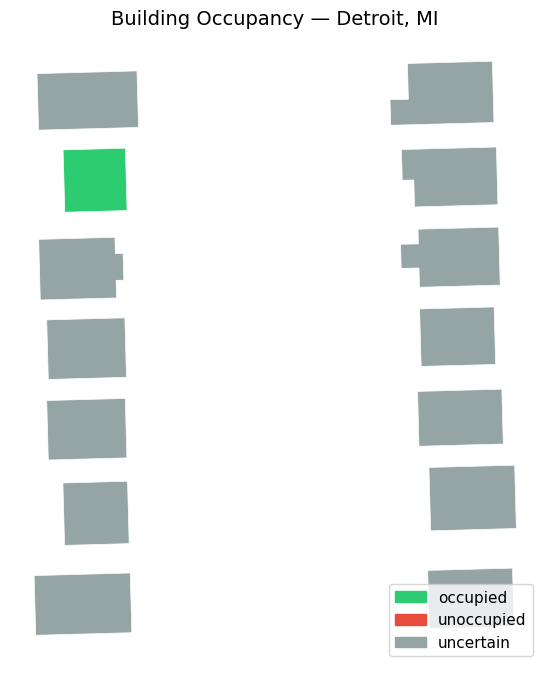

In [23]:
# 7.2  Map the labels
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if "occupancy" in labeled_gdf.columns:
    color_map = {
        "occupied":   "#2ecc71",
        "unoccupied": "#e74c3c",
        "uncertain":  "#95a5a6",
    }
    labeled_gdf["color"] = labeled_gdf["occupancy"].map(color_map).fillna("#cccccc")

    fig, ax = plt.subplots(figsize=(10, 7))
    labeled_gdf.plot(ax=ax, color=labeled_gdf["color"], edgecolor="white", linewidth=0.5)
    ax.set_title("Building Occupancy — Detroit, MI", fontsize=14)
    ax.set_axis_off()

    legend_patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
    ax.legend(handles=legend_patches, loc="lower right", fontsize=11)
    plt.tight_layout()
    plt.show()

In [24]:
# 7.3  Save the labeled GeoDataFrame
# GeoJSON is readable by QGIS, Leaflet, and most mapping tools.
geojson_path = DATASET_DIR / "labeled_buildings.geojson"

if "occupancy" in labeled_gdf.columns:
    labeled_gdf.drop(columns=["color"], errors="ignore").to_file(
        geojson_path, driver="GeoJSON"
    )
    print(f"Saved: {geojson_path}")

Saved: my_dataset/labeled_buildings.geojson


---
## 8 · Tips, tricks, and troubleshooting

### Checkpoint files

| Situation | What to do |
|---|---|
| Want to restart from scratch | Delete the `.jsonl` file and re-run |
| Checkpoint grew stale (e.g. you changed the bbox) | Delete and re-run |
| Want to inspect what's saved | `pd.read_json("path.jsonl", lines=True)` |
| JSONL is very large | The `data` column stores base64 images inline; for large datasets, fetch once then use `download_to_dir` and the filesystem as your single source of truth |

> **Two-checkpoint model in brief:**  
> `get_svi_from_locations(checkpoint_path=...)` → JSONL checkpoint guards against API re-hits.  
> `download_to_dir(...)` → Filesystem guards against redundant downloads (no extra checkpoint needed).

### Improving label quality

1. **Iterate on the prompt.** Run on 10–20 images, inspect `visual_evidence`, revise the prompt, repeat.
2. **Use a stronger model.** If `uncertain` > 20%, try Claude Sonnet or GPT-4o instead of mini/Haiku.
3. **Filter bad images first.** Check `gtd.svi_metadata` for images with unusual capture dates or angles.
4. **Multi-view majority vote.** Use `multi_num=2` or `3` during collection — multiple views per building reduce single-image noise.

### Common errors

| Error | Fix |
|---|---|
| `No Mapillary key` | Set `MAPILLARY_KEY` in cell 0 |
| `Ollama connection refused` | Run `ollama serve` in a terminal |
| Model times out | Increase `max_new_tokens` or switch to a smaller model |
| Inference crashes at image N | Just re-run — `checkpoint_path` will skip images 0 through N-1 |

### What to build next

- **Multi-city comparison** — reuse the same schema on a different bbox
- **Time-series** — repeat collection with `year=[2018, 2020]` and compare labels over time
- **Multi-modal** — combine SVIs with audio (`get_sound_from_location`) or photos (`get_photo_from_location`)

---
## Complete run summary

Here's what the full pipeline produces — run this cell after completing all steps above.

In [25]:
# Final summary
print("═" * 55)
print(" urbanworm  ·  ground-truth labeling run summary")
print("═" * 55)

print(f"\n📍 Study area:    Detroit, MI  ({BBOX})")
print(f"🏠 Buildings:     {len(gtd.units)}")
print(f"📸 Street views:  {len(gtd.svis.get('id', []))}")

print("\n📂 Checkpoint files:")
for f in sorted(RUN_DIR.glob("*.jsonl")):
    n = sum(1 for _ in open(f))
    print(f"   {f.name:<30} {n} records")

if DATASET_DIR.exists() and (DATASET_DIR / 'metadata.csv').exists():
    meta_final = pd.read_csv(DATASET_DIR / 'metadata.csv')
    imgs = list((DATASET_DIR / 'images').glob('*.png')) if (DATASET_DIR / 'images').exists() else []
    print(f"\n📊 Dataset:")
    print(f"   metadata.csv          {len(meta_final)} rows × {len(meta_final.columns)} columns")
    print(f"   images/               {len(imgs)} image files")
    if 'occupancy1' in meta_final.columns:
        dist = meta_final['occupancy1'].value_counts().to_dict()
        print(f"   label distribution    {dist}")

print("\n✅ Done")

═══════════════════════════════════════════════════════
 urbanworm  ·  ground-truth labeling run summary
═══════════════════════════════════════════════════════

📍 Study area:    Detroit, MI  ((-83.208003, 42.374646, -83.206608, 42.375328))
🏠 Buildings:     14
📸 Street views:  28

📂 Checkpoint files:
   labels_ollama.jsonl            28 records
   svi.jsonl                      19 records

📊 Dataset:
   metadata.csv          56 rows × 8 columns
   images/               28 image files
   label distribution    {'uncertain': 46, 'occupied': 10}

✅ Done
